In [3]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

# Problem parameters
T = 40  # 40 years until retirement
n = 3   # 3 assets: stocks, bonds, cash
rho = 0.5  # Risk aversion parameter
beta = 0.9  # Bequest importance

# Asset parameters (annual returns)
mu = np.array([0.08, 0.04, 0.02])  # Expected returns: stocks, bonds, cash
# Covariance matrix (how assets move together)
Sigma = np.array([
    [0.04, 0.01, 0.0001],   # Stocks
    [0.01, 0.0225, 0.0001], # Bonds
    [0.0001, 0.0001, 0.0001] # Cash
])

# Labor income (grows with experience, then plateaus)
years = np.arange(T)
y = 60000 * np.ones(T)
y[:10] = 60000 + 2000 * np.arange(10)  # Growth phase
y[10:30] = 80000  # Peak earning years
y[30:] = 70000  # Pre-retirement phase

# Initial wealth
k0 = 10000

# Risk-free rate (approx. cash return)
mu_rf = mu[2]

# Present value of future labor income
v = np.zeros(T)
for t in range(T):
    for tau in range(t, T):
        v[t] += y[tau] * np.exp(-mu_rf * (tau - t))

# Scale down the problem to improve numerical stability
# We'll work in units of $10,000 to avoid very large numbers
scale_factor = 10000
y_scaled = y / scale_factor
k0_scaled = k0 / scale_factor
v_scaled = v / scale_factor

print("Data prepared successfully!")
print(f"Initial wealth: ${k0:,.0f}")
print(f"Average annual income: ${np.mean(y):,.0f}")
print(f"Final year income: ${y[-1]:,.0f}")

Data prepared successfully!
Initial wealth: $10,000
Average annual income: $74,750
Final year income: $70,000


                                     CVXPY                                     
                                     v1.4.2                                    
(CVXPY) Aug 25 12:12:44 PM: Your problem has 201 variables, 122 constraints, and 0 parameters.
(CVXPY) Aug 25 12:12:44 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Aug 25 12:12:44 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Aug 25 12:12:44 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Aug 25 12:12:44 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Aug 25 12:12:44 PM: Compiling problem (target solver=ECOS).
(

C:\Users\zhou1\anaconda3\lib\site-packages\cvxpy\problems\problem.py:1403: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


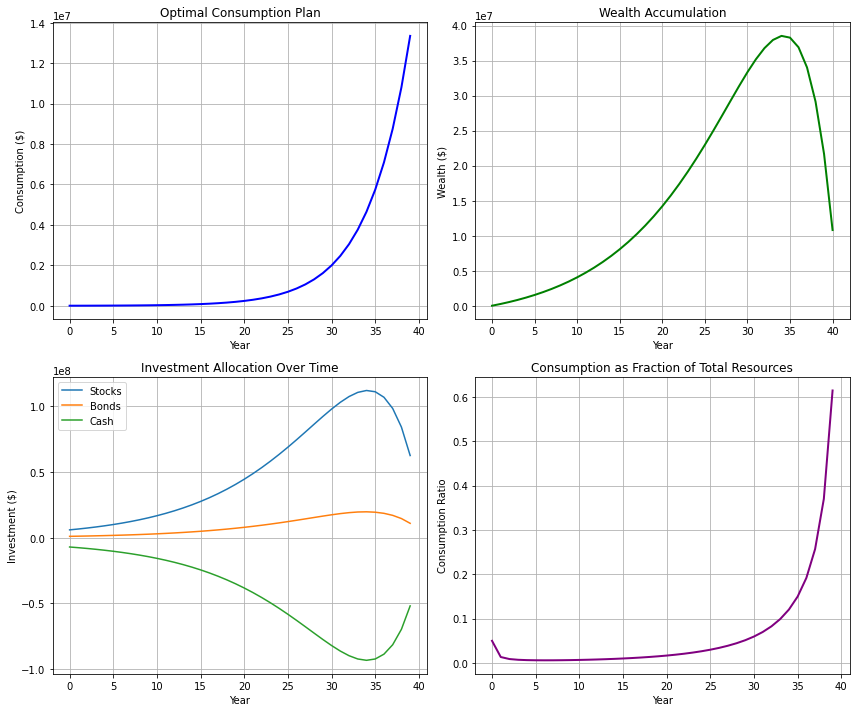


Summary Statistics:
Final wealth: $10,811,969.08
Total consumption: $70,147,682.33
Average consumption: $1,753,692.06
Initial consumption: $3,506.96
Final consumption: $13,351,687.12


In [4]:
# Implement the Merton model with better scaling
k = cp.Variable(T+1)  # Wealth at each time period (scaled)
h = cp.Variable((n, T))  # Amount invested in each asset at each time (scaled)
c = cp.Variable(T, nonneg=True)  # Consumption at each time (scaled, non-negative)

# Cholesky decomposition of covariance matrix
try:
    Sigma_half = np.linalg.cholesky(Sigma)
except:
    # If Cholesky fails, use eigenvalue decomposition
    eigvals, eigvecs = np.linalg.eig(Sigma)
    Sigma_half = eigvecs @ np.diag(np.sqrt(np.maximum(eigvals, 0))) @ eigvecs.T

# Objective function (scaled)
objective = beta/rho * cp.power(k[T], rho) + 1/rho * cp.sum(cp.power(c, rho))

# Constraints
constraints = [k[0] == k0_scaled]  # Initial wealth
constraints += [k[:-1] == cp.sum(h, axis=0)]  # Wealth fully invested

# Add dynamics constraints
for t in range(T):
    risk_adjustment = (1-rho)/2 * cp.quad_over_lin(Sigma_half.T @ h[:,t], k[t] + v_scaled[t])
    constraints += [
        k[t+1] <= k[t] - c[t] + y_scaled[t] + mu.T @ h[:,t] - risk_adjustment,
        c[t] >= 0.001,  # Minimum consumption to avoid numerical issues
        k[t] + v_scaled[t] >= 0.001  # Ensure positive denominator
    ]

# Form and solve problem
prob = cp.Problem(cp.Maximize(objective), constraints)

# Try different solvers
try:
    prob.solve(solver=cp.ECOS, verbose=True)
except:
    try:
        prob.solve(solver=cp.SCS, verbose=True)
    except:
        try:
            prob.solve(solver=cp.CVXOPT, verbose=True)
        except:
            print("All solvers failed. Please check the problem formulation.")

if prob.status in ["infeasible", "unbounded"]:
    print(f"Problem is {prob.status}. Please check the constraints.")
else:
    print(f"Problem status: {prob.status}")
    print(f"Optimal value: ${prob.value * scale_factor:,.2f}")
    
    # Rescale back to original units
    c_opt = c.value * scale_factor
    k_opt = k.value * scale_factor
    h_opt = h.value * scale_factor
    
    # Plot results
    plt.figure(figsize=(12, 10))
    
    # Consumption plan
    plt.subplot(2, 2, 1)
    plt.plot(range(T), c_opt, 'b-', linewidth=2)
    plt.xlabel('Year')
    plt.ylabel('Consumption ($)')
    plt.title('Optimal Consumption Plan')
    plt.grid(True)
    
    # Wealth accumulation
    plt.subplot(2, 2, 2)
    plt.plot(range(T+1), k_opt, 'g-', linewidth=2)
    plt.xlabel('Year')
    plt.ylabel('Wealth ($)')
    plt.title('Wealth Accumulation')
    plt.grid(True)
    
    # Investment allocation over time
    plt.subplot(2, 2, 3)
    asset_names = ['Stocks', 'Bonds', 'Cash']
    for i in range(n):
        plt.plot(range(T), h_opt[i,:], label=asset_names[i])
    plt.xlabel('Year')
    plt.ylabel('Investment ($)')
    plt.title('Investment Allocation Over Time')
    plt.legend()
    plt.grid(True)
    
    # Consumption as percentage of wealth+income
    plt.subplot(2, 2, 4)
    consumption_ratio = c_opt / (k_opt[:-1] + y)
    plt.plot(range(T), consumption_ratio, 'purple', linewidth=2)
    plt.xlabel('Year')
    plt.ylabel('Consumption Ratio')
    plt.title('Consumption as Fraction of Total Resources')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Print some summary statistics
    print("\nSummary Statistics:")
    print(f"Final wealth: ${k_opt[-1]:,.2f}")
    print(f"Total consumption: ${sum(c_opt):,.2f}")
    print(f"Average consumption: ${np.mean(c_opt):,.2f}")
    print(f"Initial consumption: ${c_opt[0]:,.2f}")
    print(f"Final consumption: ${c_opt[-1]:,.2f}")

In [5]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

# Problem parameters
T = 40  # 40 years until retirement
n = 3   # 3 assets: stocks, bonds, cash
rho = 0.5  # Risk aversion parameter
beta = 0.9  # Bequest importance

# Time-dependent weights for consumption (higher when young)
# Let's create weights that decrease exponentially over time
gamma = np.exp(-0.05 * np.arange(T))  # Higher weight for early consumption
gamma = gamma / np.max(gamma)  # Normalize to max value of 1

# Asset parameters (annual returns)
mu = np.array([0.08, 0.04, 0.02])  # Expected returns: stocks, bonds, cash
# Covariance matrix (how assets move together)
Sigma = np.array([
    [0.04, 0.01, 0.0001],   # Stocks
    [0.01, 0.0225, 0.0001], # Bonds
    [0.0001, 0.0001, 0.0001] # Cash
])

# Labor income (grows with experience, then plateaus)
years = np.arange(T)
y = 60000 * np.ones(T)
y[:10] = 60000 + 2000 * np.arange(10)  # Growth phase
y[10:30] = 80000  # Peak earning years
y[30:] = 70000  # Pre-retirement phase

# Initial wealth
k0 = 10000

# Risk-free rate (approx. cash return)
mu_rf = mu[2]

# Present value of future labor income
v = np.zeros(T)
for t in range(T):
    for tau in range(t, T):
        v[t] += y[tau] * np.exp(-mu_rf * (tau - t))

# Scale down the problem to improve numerical stability
scale_factor = 10000
y_scaled = y / scale_factor
k0_scaled = k0 / scale_factor
v_scaled = v / scale_factor
gamma_scaled = gamma  # Already normalized

print("Data prepared successfully!")
print(f"Time-dependent weights: {gamma[:5]}... (decreasing over time)")

Data prepared successfully!
Time-dependent weights: [1.         0.95122942 0.90483742 0.86070798 0.81873075]... (decreasing over time)


C:\Users\zhou1\anaconda3\lib\site-packages\cvxpy\problems\problem.py:1403: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Problem status: optimal_inaccurate
Optimal value: $2,954,051.56


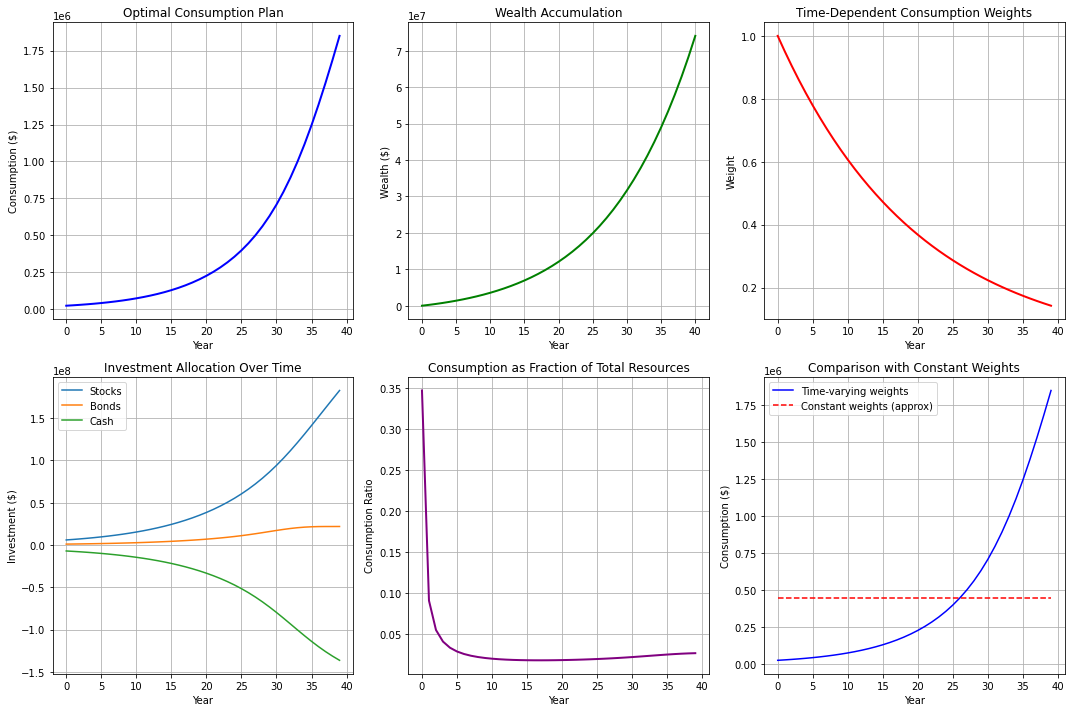


Summary Statistics:
Final wealth: $74,077,945.41
Total consumption: $17,899,473.69
Average consumption: $447,486.84
Initial consumption: $24,310.06
Final consumption: $1,849,838.78
Consumption ratio (early/late): 0.01


In [6]:
# Implement the Merton model with time-dependent preferences
k = cp.Variable(T+1)  # Wealth at each time period (scaled)
h = cp.Variable((n, T))  # Amount invested in each asset at each time (scaled)
c = cp.Variable(T, nonneg=True)  # Consumption at each time (scaled, non-negative)

# Cholesky decomposition of covariance matrix
try:
    Sigma_half = np.linalg.cholesky(Sigma)
except:
    # If Cholesky fails, use eigenvalue decomposition
    eigvals, eigvecs = np.linalg.eig(Sigma)
    Sigma_half = eigvecs @ np.diag(np.sqrt(np.maximum(eigvals, 0))) @ eigvecs.T

# Objective function with time-dependent weights
objective = beta/rho * cp.power(k[T], rho) + (1/rho) * cp.sum(cp.multiply(gamma_scaled, cp.power(c, rho)))

# Constraints
constraints = [k[0] == k0_scaled]  # Initial wealth
constraints += [k[:-1] == cp.sum(h, axis=0)]  # Wealth fully invested

# Add dynamics constraints
for t in range(T):
    risk_adjustment = (1-rho)/2 * cp.quad_over_lin(Sigma_half.T @ h[:,t], k[t] + v_scaled[t])
    constraints += [
        k[t+1] <= k[t] - c[t] + y_scaled[t] + mu.T @ h[:,t] - risk_adjustment,
        c[t] >= 0.001,  # Minimum consumption to avoid numerical issues
        k[t] + v_scaled[t] >= 0.001  # Ensure positive denominator
    ]

# Form and solve problem
prob = cp.Problem(cp.Maximize(objective), constraints)

# Try different solvers
try:
    prob.solve(solver=cp.ECOS, verbose=False)
except:
    try:
        prob.solve(solver=cp.SCS, verbose=False)
    except:
        try:
            prob.solve(solver=cp.CVXOPT, verbose=False)
        except:
            print("All solvers failed. Please check the problem formulation.")

if prob.status in ["infeasible", "unbounded"]:
    print(f"Problem is {prob.status}. Please check the constraints.")
else:
    print(f"Problem status: {prob.status}")
    print(f"Optimal value: ${prob.value * scale_factor:,.2f}")
    
    # Rescale back to original units
    c_opt = c.value * scale_factor
    k_opt = k.value * scale_factor
    h_opt = h.value * scale_factor
    
    # Plot results
    plt.figure(figsize=(15, 10))
    
    # Consumption plan
    plt.subplot(2, 3, 1)
    plt.plot(range(T), c_opt, 'b-', linewidth=2)
    plt.xlabel('Year')
    plt.ylabel('Consumption ($)')
    plt.title('Optimal Consumption Plan')
    plt.grid(True)
    
    # Wealth accumulation
    plt.subplot(2, 3, 2)
    plt.plot(range(T+1), k_opt, 'g-', linewidth=2)
    plt.xlabel('Year')
    plt.ylabel('Wealth ($)')
    plt.title('Wealth Accumulation')
    plt.grid(True)
    
    # Time-dependent weights
    plt.subplot(2, 3, 3)
    plt.plot(range(T), gamma, 'r-', linewidth=2)
    plt.xlabel('Year')
    plt.ylabel('Weight')
    plt.title('Time-Dependent Consumption Weights')
    plt.grid(True)
    
    # Investment allocation over time
    plt.subplot(2, 3, 4)
    asset_names = ['Stocks', 'Bonds', 'Cash']
    for i in range(n):
        plt.plot(range(T), h_opt[i,:], label=asset_names[i])
    plt.xlabel('Year')
    plt.ylabel('Investment ($)')
    plt.title('Investment Allocation Over Time')
    plt.legend()
    plt.grid(True)
    
    # Consumption as percentage of wealth+income
    plt.subplot(2, 3, 5)
    consumption_ratio = c_opt / (k_opt[:-1] + y)
    plt.plot(range(T), consumption_ratio, 'purple', linewidth=2)
    plt.xlabel('Year')
    plt.ylabel('Consumption Ratio')
    plt.title('Consumption as Fraction of Total Resources')
    plt.grid(True)
    
    # Compare with constant weights (for reference)
    plt.subplot(2, 3, 6)
    # Simple approximation of what constant weights would give
    constant_consumption = np.ones(T) * np.mean(c_opt)
    plt.plot(range(T), c_opt, 'b-', label='Time-varying weights')
    plt.plot(range(T), constant_consumption, 'r--', label='Constant weights (approx)')
    plt.xlabel('Year')
    plt.ylabel('Consumption ($)')
    plt.title('Comparison with Constant Weights')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Print some summary statistics
    print("\nSummary Statistics:")
    print(f"Final wealth: ${k_opt[-1]:,.2f}")
    print(f"Total consumption: ${sum(c_opt):,.2f}")
    print(f"Average consumption: ${np.mean(c_opt):,.2f}")
    print(f"Initial consumption: ${c_opt[0]:,.2f}")
    print(f"Final consumption: ${c_opt[-1]:,.2f}")
    print(f"Consumption ratio (early/late): {c_opt[0]/c_opt[-1]:.2f}")